# Lab 2: Numerical Differentiation and Gradient Descent

### Task 1: Numerical Gradient

For a scalar-valued function

$$
f : \mathbb{R}^n \to \mathbb{R},
$$

the gradient of $f$ at $\mathbf{x}$ is defined as

$$
\nabla f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$$

Implement a general function to approximate the gradient numerically using the forward finite-difference formula:

$$
\frac{\partial f(\mathbf{x})}{\partial x_i}
\approx
\frac{f(\mathbf{x}+h\mathbf{e}_i)-f(\mathbf{x})}{h},
$$

where $h>0$ is a small step size and $\mathbf{e}_i$ is the $i^{\text{th}}$ standard basis vector.

Use the following functions:

$$
f_1(x)=2x^2+3x+1
$$

and

$$
f_2(x,y)=2x^2+xy+3y^2-4x+2y+5
$$

Compute the numerical gradient at suitable points.

In [1]:
import numpy as np
def numerical_gradient(function, point, h=0.00001):
    point = np.array(point, dtype=float)
    original_value = function(point)
    gradient = np.zeros_like(point)
    for i in range(len(point)):
        new_point = point.copy()
        new_point[i] = new_point[i] + h
        new_value = function(new_point)
        gradient[i] = (new_value - original_value) / h
    return gradient
def f1(point):
    x = point[0]
    return 2 * x**2 + 3 * x + 1
def f2(point):
    x = point[0]
    y = point[1]
    return 2 * x**2 + x * y + 3 * y**2 - 4 * x + 2 * y + 5

point1 = [2]
gradient1 = numerical_gradient(f1, point1)
point2 = [1, 2]
gradient2 = numerical_gradient(f2, point2)

print("Gradient of f1 at x = 2:", gradient1)
print("Gradient of f2 at (x, y) = (1, 2):", gradient2)

Gradient of f1 at x = 2: [11.00002]
Gradient of f2 at (x, y) = (1, 2): [ 2.00002 15.00003]


### Task 2: Numerical Hessian

For a scalar-valued function

$$
f : \mathbb{R}^n \to \mathbb{R},
$$

the gradient is

$$
\nabla f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$$

The Hessian is obtained by differentiating the gradient with respect to the input variables:

$$
H(\mathbf{x}) = \nabla^2 f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2}
&
\frac{\partial^2 f}{\partial x_1\partial x_2}
&
\cdots
&
\frac{\partial^2 f}{\partial x_1\partial x_n}
\\
\frac{\partial^2 f}{\partial x_2\partial x_1}
&
\frac{\partial^2 f}{\partial x_2^2}
&
\cdots
&
\frac{\partial^2 f}{\partial x_2\partial x_n}
\\
\vdots
&
\vdots
&
\ddots
&
\vdots
\\
\frac{\partial^2 f}{\partial x_n\partial x_1}
&
\frac{\partial^2 f}{\partial x_n\partial x_2}
&
\cdots
&
\frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}.
$$

Using the numerical gradient implemented in Task 1, approximate the $i^{\text{th}}$ column of the Hessian as

$$
H_{:,i}(\mathbf{x})
\approx
\frac{\nabla f(\mathbf{x}+h\mathbf{e}_i)-\nabla f(\mathbf{x})}{h},
$$

where $\mathbf{e}_i$ is the $i^{\text{th}}$ standard basis vector.

In the above expression, both gradient terms must be evaluated using the numerical gradient function developed in Task 1.

Implement a general function:

$$
\texttt{numerical\_hessian}(f,\mathbf{x},h)
$$

by performing the following steps:

1. Compute the numerical gradient at $\mathbf{x}$.
2. Perturb one input variable at a time by $h$.
3. Recompute the numerical gradient at the perturbed point.
4. Use the change in gradient to obtain the corresponding column of the Hessian.

Calculate the numerical Hessian for both $f_1$ and $f_2$ at the same points used in Task 1.

In [2]:
import numpy as np
def numerical_hessian(function, point, h=0.00001):
    point = np.array(point, dtype=float)
    original_gradient = numerical_gradient(function, point, h)
    hessian = np.zeros((len(point), len(point)))
    for i in range(len(point)):
        new_point = point.copy()
        new_point[i] = new_point[i] + h
        new_gradient = numerical_gradient(function, new_point, h)
        hessian[:, i] = (new_gradient - original_gradient) / h
    return hessian
hessian1 = numerical_hessian(f1, point1)
hessian2 = numerical_hessian(f2, point2)
print(hessian1)
print(hessian2)

[[4.00000033]]
[[3.9999648  0.99998232]
 [0.99998232 6.00003602]]


Task 3: Validation with Analytical Derivatives
For f1 and f2:
1. Derive and implement the analytical gradient.
2. Derive and implement the analytical Hessian.
3. Compare analytical and numerical gradients.
4. Compare analytical and numerical Hessians.
5. Report the absolute error between the two results

In [3]:
def analytical_gradient_f1(point):
    x = point[0]
    return np.array([4 * x + 3])
def analytical_gradient_f2(point):
    x = point[0]
    y = point[1]
    gradient_x = 4 * x + y - 4
    gradient_y = x + 6 * y + 2
    return np.array([gradient_x, gradient_y])

def analytical_hessian_f1(point):
    return np.array([[4]])
def analytical_hessian_f2(point):
    return np.array([
        [4, 1],
        [1, 6]
    ])

numerical_gradient_1 = numerical_gradient(f1, point1)
analytical_gradient_1 = analytical_gradient_f1(point1)

numerical_hessian_1 = numerical_hessian(f1, point1)
analytical_hessian_1 = analytical_hessian_f1(point1)

numerical_gradient_2 = numerical_gradient(f2, point2)
analytical_gradient_2 = analytical_gradient_f2(point2)

numerical_hessian_2 = numerical_hessian(f2, point2)
analytical_hessian_2 = analytical_hessian_f2(point2)

gradient_error_1 = np.abs(analytical_gradient_1 - numerical_gradient_1)
hessian_error_1 = np.abs(analytical_hessian_1 - numerical_hessian_1)
gradient_error_2 = np.abs(analytical_gradient_2 - numerical_gradient_2)
hessian_error_2 = np.abs(analytical_hessian_2 - numerical_hessian_2)


print("Gradient Absolute Error: ",end = " ")
print(gradient_error_1)
print()
print("Hessian Absolute Error: ",end = " ")
print(hessian_error_1)
print()

print("Gradient Absolute Error: ",end = " ")
print(gradient_error_2)
print()
print("Hessian Absolute Error: ",end = " ")
print(hessian_error_2)

Gradient Absolute Error:  [2.00001181e-05]

Hessian Absolute Error:  [[3.30961484e-07]]

Gradient Absolute Error:  [2.00002812e-05 2.99999675e-05]

Hessian Absolute Error:  [[3.51961753e-05 1.76808280e-05]
 [1.76808280e-05 3.60235790e-05]]


# Task 4: Numerical Gradient for Linear Regression

Use the **California Housing Dataset** and consider only:

- Input feature: `MedInc`
- Target: `MedHouseValue`

Use the same data splitting and standardization procedure followed in Lab 1.

The Linear Regression model is:

$$
\hat{y} = \theta_0 + \theta_1 x
$$

with Mean Squared Error:

$$
J(\theta) =
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)^2
$$

Implement the gradient of the MSE using:

- Analytical differentiation
- Numerical differentiation

Use the same initialization, learning rate and number of iterations for both methods.

Compare gradients and report the difference.

In [4]:
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()
x = housing_data.data[:, 0]
y = housing_data.target
np.random.seed(42)
total_rows = len(x)
shuffle = np.random.permutation(total_rows)
train_size = int(0.6 * total_rows)
validation_size = int(0.2 * total_rows)
train_indexes = shuffle[:train_size]
validation_indexes = shuffle[train_size:train_size + validation_size]
test_indexes = shuffle[train_size + validation_size:]

x_train = x[train_indexes]
y_train = y[train_indexes]

x_validation = x[validation_indexes]
y_validation = y[validation_indexes]

x_test = x[test_indexes]
y_test = y[test_indexes]

train_mean = np.mean(x_train)
train_std = np.std(x_train)

x_train = (x_train - train_mean) / train_std
x_validation = (x_validation - train_mean) / train_std
x_test = (x_test - train_mean) / train_std

x_train = np.column_stack((np.ones(len(x_train)), x_train))
x_validation = np.column_stack((np.ones(len(x_validation)), x_validation))
x_test = np.column_stack((np.ones(len(x_test)), x_test))

def calculate_mse(x, y, theta):
    prediction = x @ theta
    error = prediction - y
    mse = np.mean(error ** 2)
    return mse

def analytical_gradient(x, y, theta):
    prediction = x @ theta
    error = prediction - y
    gradient = (2 / len(y)) * (x.T @ error)
    return gradient

def numerical_gradient(x, y, theta, h=0.00001):
    gradient = np.zeros_like(theta)
    original_mse = calculate_mse(x, y, theta)
    for i in range(len(theta)):
        new_theta = theta.copy()
        new_theta[i] = new_theta[i] + h
        new_mse = calculate_mse(x,y,new_theta)
        gradient[i] = (new_mse - original_mse)/ h
    return gradient

def analytical_gradient_descent(x,y,learning_rate,iterations):
    theta = np.zeros(x.shape[1])
    gradient_history = []
    for i in range(iterations):
        gradient = analytical_gradient(x,y,theta)
        theta = theta - learning_rate * gradient
        gradient_history.append(gradient.copy())
    return theta, gradient_history

def numerical_gradient_descent(x,y,learning_rate,iterations):
    theta = np.zeros(x.shape[1])
    gradient_history = []
    for i in range(iterations):
        gradient = numerical_gradient(x,y,theta)
        theta = theta - learning_rate * gradient
        gradient_history.append(gradient.copy())
    return theta, gradient_history

learning_rate = 0.1
iterations = 10
analytical_theta, analytical_history = (analytical_gradient_descent(x_train,y_train,learning_rate,iterations))
numerical_theta, numerical_history = (numerical_gradient_descent(x_train,y_train,learning_rate,iterations))
print("Analytical Theta:")
print(analytical_theta)
print()
print("Numerical Theta:")
print(numerical_theta)
print()
print("Theta Absolute Difference:")
print(np.abs(analytical_theta - numerical_theta))
print()
print("Gradient Comparison")
print()
final_gradient_difference = np.abs(analytical_history[-1] - numerical_history[-1])
print("Final Gradient Difference:", final_gradient_difference)

Analytical Theta:
[1.84862279 0.705139  ]

Numerical Theta:
[1.84861833 0.70513453]

Theta Absolute Difference:
[4.46312889e-06 4.46313231e-06]

Gradient Comparison

Final Gradient Difference: [1.34218539e-06 1.34218589e-06]


# Task 5: Batch, Mini-Batch and Stochastic Gradient Descent

Using the Linear Regression model from Task 4, implement:

- Batch Gradient Descent
- Mini-Batch Gradient Descent
- Stochastic Gradient Descent

Run each method using:

- Analytical Gradient
- Numerical Gradient

Plot:

- Epoch vs Training MSE
- Epoch vs Validation MSE
- Bar plot comparing execution time

Write conclusions comparing:

- Analytical and numerical gradients.
- Batch, Mini-Batch and Stochastic Gradient Descent.
- Convergence behaviour.

In [5]:
import time
def batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,gradient_function):
    theta = np.zeros(x_train.shape[1])
    train_losses = []
    validation_losses = []
    for epoch in range(epochs):
        gradient = gradient_function(x_train,y_train,theta)
        theta = theta - learning_rate * gradient
        train_loss = calculate_mse(x_train,y_train,theta)
        validation_loss = calculate_mse(x_validation,y_validation,theta)
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
    return theta, train_losses, validation_losses
def mini_batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,batch_size,gradient_function):
    theta = np.zeros(x_train.shape[1])
    train_losses = []
    validation_losses = []
    for epoch in range(epochs):
        indexes = np.random.permutation(len(x_train))
        x_shuffled = x_train[indexes]
        y_shuffled = y_train[indexes]
        for start in range(0, len(x_train), batch_size):
            end = start + batch_size
            x_batch = x_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            gradient = gradient_function(x_batch,y_batch,theta)
            theta = theta - learning_rate * gradient
        train_loss = calculate_mse(x_train,y_train,theta)
        validation_loss = calculate_mse(x_validation,y_validation,theta)
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
    return theta, train_losses, validation_losses
def stochastic_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,gradient_function):
    theta = np.zeros(x_train.shape[1])
    train_losses = []
    validation_losses = []
    for epoch in range(epochs):
        indexes = np.random.permutation(len(x_train))
        x_shuffled = x_train[indexes]
        y_shuffled = y_train[indexes]
        for j in range(len(x_train)):
            x_sample = x_shuffled[j:j + 1]
            y_sample = y_shuffled[j:j + 1]
            gradient = gradient_function(x_sample,y_sample,theta)
            theta = theta - learning_rate * gradient
        train_loss = calculate_mse(x_train,y_train,theta)
        validation_loss = calculate_mse(x_validation,y_validation,theta)
        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
    return theta, train_losses, validation_losses
learning_rate = 0.01
epochs = 50
batch_size = 32

start_time = time.time()
batch_analytical_theta, batch_analytical_train_losses, batch_analytical_validation_losses = batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,analytical_gradient)
batch_analytical_time = time.time() - start_time
print("Batch GD using Analytical Gradient")
print("Theta:", batch_analytical_theta)
print("Execution Time:", batch_analytical_time)

start_time = time.time()
batch_numerical_theta, batch_numerical_train_losses, batch_numerical_validation_losses = batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,numerical_gradient)
batch_numerical_time = time.time() - start_time
print("Batch GD using Numerical Gradient")
print("Theta:", batch_numerical_theta)
print("Execution Time:", batch_numerical_time)

start_time = time.time()
mini_batch_analytical_theta, mini_batch_analytical_train_losses, mini_batch_analytical_validation_losses = mini_batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,batch_size,analytical_gradient)
mini_batch_analytical_time = time.time() - start_time
print("Mini-Batch GD using Analytical Gradient")
print("Theta:", mini_batch_analytical_theta)
print("Execution Time:", mini_batch_analytical_time)

start_time = time.time()
mini_batch_numerical_theta, mini_batch_numerical_train_losses, mini_batch_numerical_validation_losses = mini_batch_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,batch_size,numerical_gradient)
mini_batch_numerical_time = time.time() - start_time
print("Mini-Batch GD using Numerical Gradient")
print("Theta:", mini_batch_numerical_theta)
print("Execution Time:", mini_batch_numerical_time)

start_time = time.time()
stochastic_analytical_theta, stochastic_analytical_train_losses, stochastic_analytical_validation_losses = stochastic_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,analytical_gradient)
stochastic_analytical_time = time.time() - start_time
print("Stochastic GD using Analytical Gradient")
print("Theta:", stochastic_analytical_theta)
print("Execution Time:", stochastic_analytical_time)

start_time = time.time()
stochastic_numerical_theta, stochastic_numerical_train_losses, stochastic_numerical_validation_losses = stochastic_gradient_descent(x_train,y_train,x_validation,y_validation,learning_rate,epochs,numerical_gradient)
stochastic_numerical_time = time.time() - start_time
print("Stochastic GD using Numerical Gradient")
print("Theta:", stochastic_numerical_theta)
print("Execution Time:", stochastic_numerical_time)


Batch GD using Analytical Gradient
Theta: [1.31680083 0.50228074]
Execution Time: 0.0094757080078125
Batch GD using Numerical Gradient
Theta: [1.31679766 0.50227756]
Execution Time: 0.012052297592163086
Mini-Batch GD using Analytical Gradient
Theta: [2.0823157  0.77389638]
Execution Time: 0.35364675521850586
Mini-Batch GD using Numerical Gradient
Theta: [2.07917861 0.81252286]
Execution Time: 1.3763556480407715
Stochastic GD using Analytical Gradient
Theta: [2.05278887 0.83979848]
Execution Time: 5.070783376693726
Stochastic GD using Numerical Gradient
Theta: [2.10279023 0.94796398]
Execution Time: 26.458237171173096


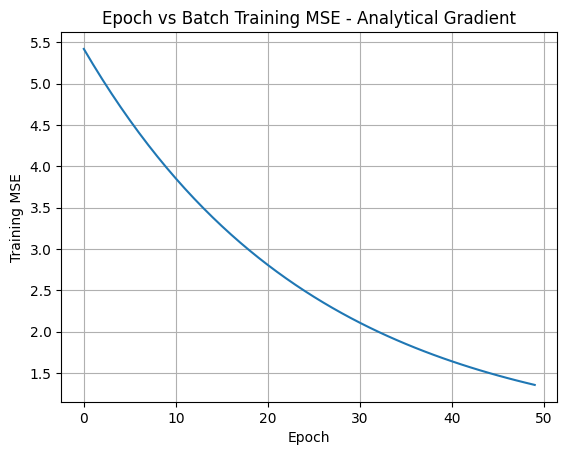

In [6]:
import matplotlib.pyplot as plt
plt.plot(batch_analytical_train_losses,label="Batch - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Batch Training MSE - Analytical Gradient")
plt.grid()
plt.show()

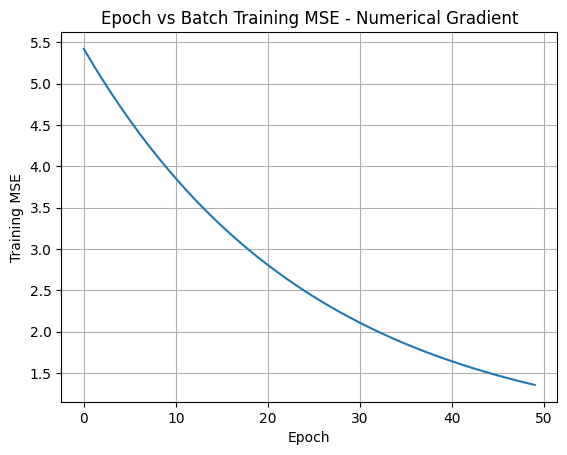

In [7]:
plt.plot(batch_numerical_train_losses,label="Batch - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Batch Training MSE - Numerical Gradient")
plt.grid()
plt.show()

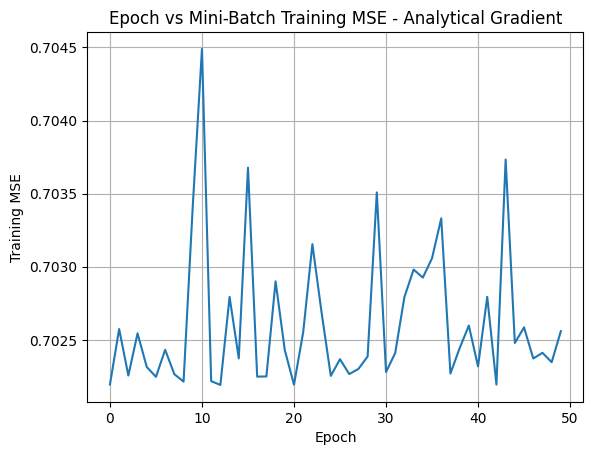

In [8]:
plt.plot(mini_batch_analytical_train_losses,label="Mini-Batch - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Mini-Batch Training MSE - Analytical Gradient")
plt.grid()
plt.show()

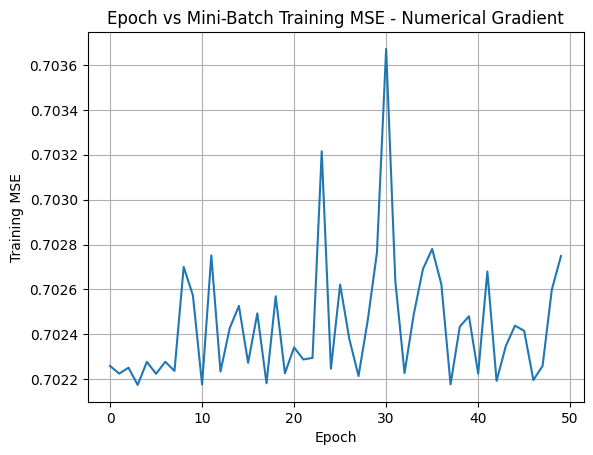

In [9]:
plt.plot(mini_batch_numerical_train_losses,label="Mini-Batch - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Mini-Batch Training MSE - Numerical Gradient")
plt.grid()
plt.show()

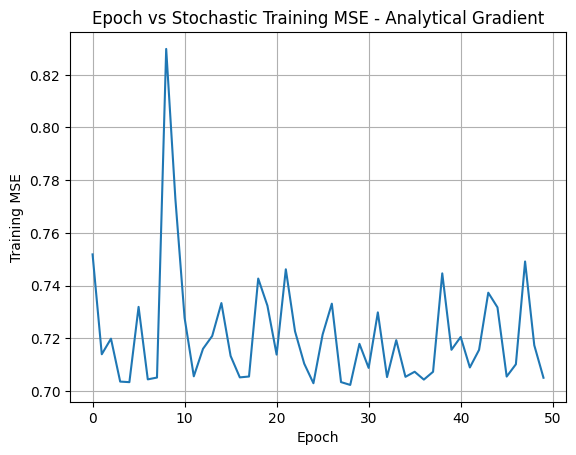

In [10]:
plt.plot(stochastic_analytical_train_losses,label="Stochastic - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Stochastic Training MSE - Analytical Gradient")
plt.grid()
plt.show()

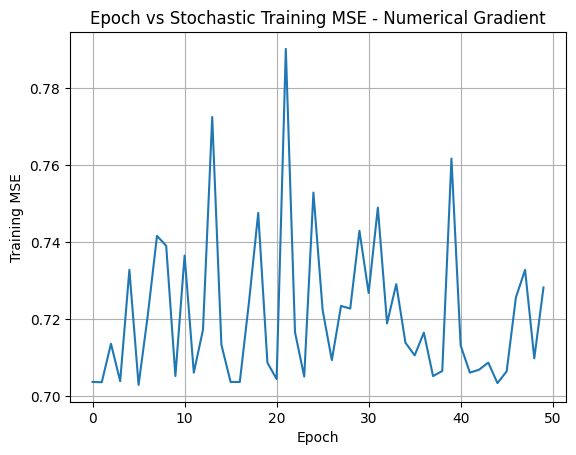

In [11]:
plt.plot(stochastic_numerical_train_losses,label="Stochastic - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Epoch vs Stochastic Training MSE - Numerical Gradient")
plt.grid()
plt.show()

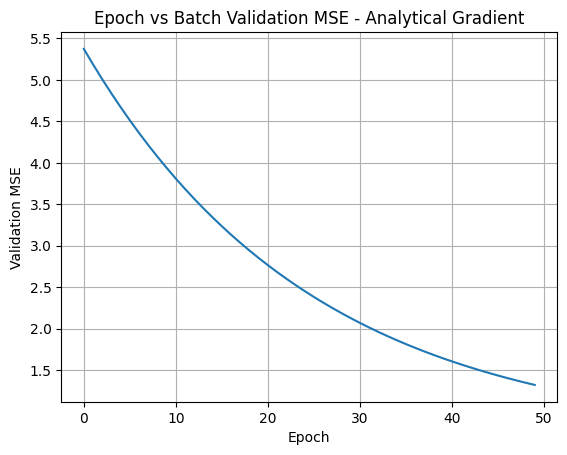

In [12]:
import matplotlib.pyplot as plt
plt.plot(batch_analytical_validation_losses,label="Batch - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Batch Validation MSE - Analytical Gradient")
plt.grid()
plt.show()

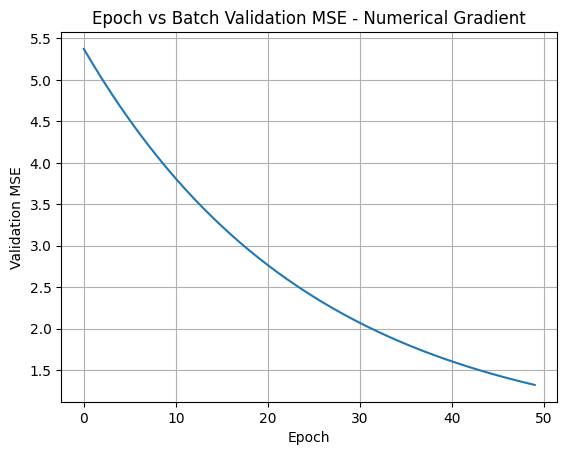

In [13]:
plt.plot(batch_numerical_validation_losses,label="Batch - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Batch Validation MSE - Numerical Gradient")
plt.grid()
plt.show()

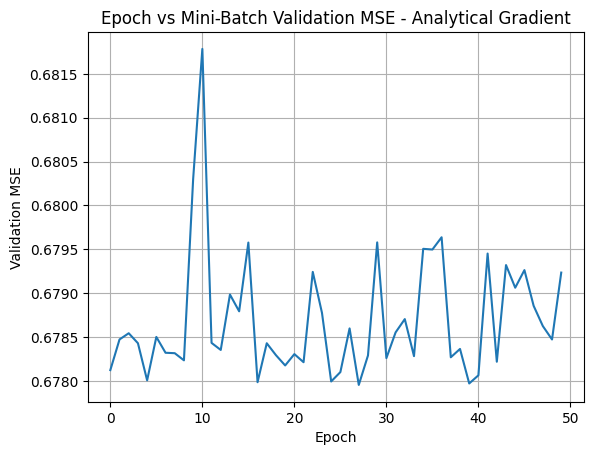

In [14]:
plt.plot(mini_batch_analytical_validation_losses,label="Mini-Batch - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Mini-Batch Validation MSE - Analytical Gradient")
plt.grid()
plt.show()

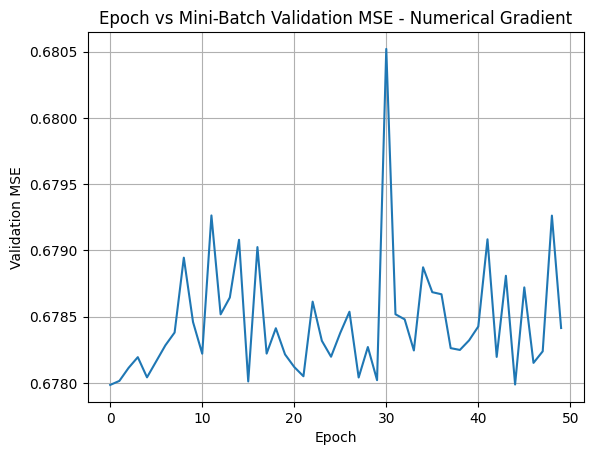

In [15]:
plt.plot(mini_batch_numerical_validation_losses,label="Mini-Batch - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Mini-Batch Validation MSE - Numerical Gradient")
plt.grid()
plt.show()

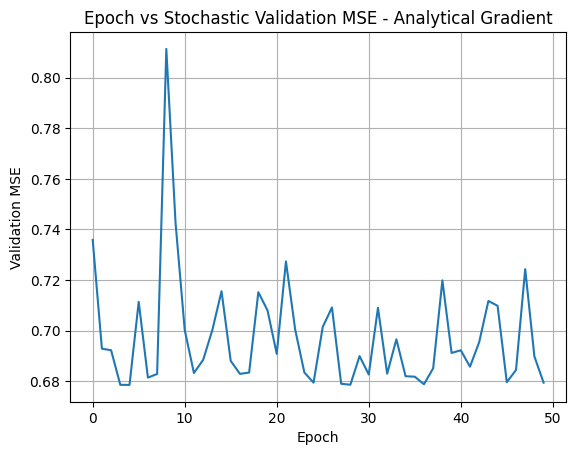

In [16]:
plt.plot(stochastic_analytical_validation_losses,label="Stochastic - Analytical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Stochastic Validation MSE - Analytical Gradient")
plt.grid()
plt.show()

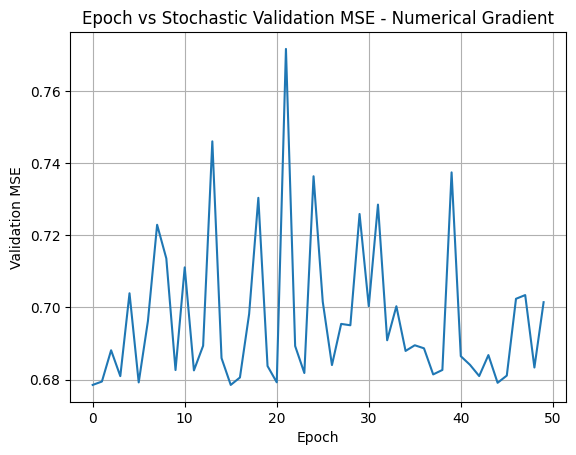

In [17]:
plt.plot(stochastic_numerical_validation_losses,label="Stochastic - Numerical")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Epoch vs Stochastic Validation MSE - Numerical Gradient")
plt.grid()
plt.show()

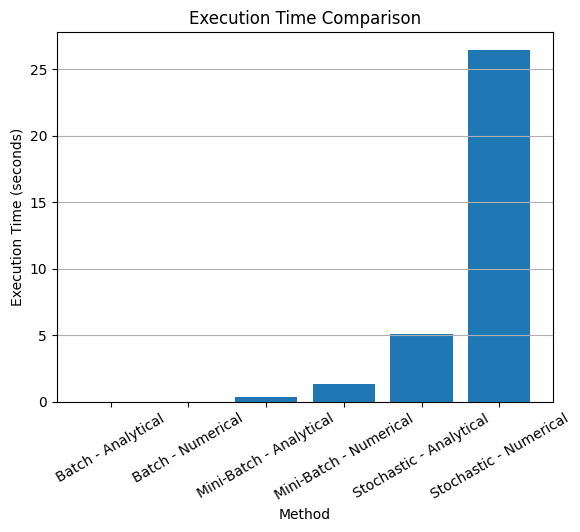

In [18]:
methods = ["Batch - Analytical","Batch - Numerical","Mini-Batch - Analytical","Mini-Batch - Numerical","Stochastic - Analytical","Stochastic - Numerical"]
execution_times = [batch_analytical_time,batch_numerical_time,mini_batch_analytical_time,mini_batch_numerical_time,stochastic_analytical_time,stochastic_numerical_time]
plt.bar(methods,execution_times)
plt.xlabel("Method")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

### Conclusion

In this experiment, Batch Gradient Descent, Mini-Batch Gradient Descent, and Stochastic Gradient Descent were studied using analytical as well as numerical gradients. The numerical gradient values were very close to the analytical values, which shows that the numerical gradient calculation was working correctly.

Batch Gradient Descent gives more stable updates because it considers the whole dataset at each step. Mini-Batch Gradient Descent uses only a small group of samples, so it gives a good combination of speed and stable learning. Stochastic Gradient Descent uses only one sample for each update, making the updates faster but less stable.

Analytical gradients are faster to calculate than numerical gradients. Numerical gradients need extra function calculations for each parameter, so they take more time. Hence, numerical gradients are mainly useful for checking whether the gradient calculation is correct, while analytical gradients are better for actual model training.

The training and validation MSE graphs helped us understand how each method converges during training. By comparing execution time, training MSE, validation MSE, and the final parameter values, we can see the differences and performance of all six approaches.
